# **Notebook 02: Retrieval Systems and Confidence Signals**

**Description:** This notebook compares BM25, dense retrieval, Hybrid RRF, and cross-encoder reranking on the fixed domain corpora, records complete-query metrics, and exports only signals available at the corresponding routing stage.

**Main Questions This Notebook Should Answer:**

- How do sparse, dense, hybrid, and reranked retrieval compare on annotated positive documents?
- Are every method and query represented before downstream generation begins?
- What retrieval signals are available before the reranking decision?
- How much measured local latency does each retrieval path consume?

---

# **Part 1: Setup and Artifact Loading**

### **Environment Setup**


In [7]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                 if (p / 'src/adaptive_rag').is_dir() and (p / 'config').is_dir())
sys.path.insert(0, str(REPO_ROOT / 'src'))
ROOT = Path(os.environ.get('ADAPTIVE_RAG_PROJECT_ROOT', REPO_ROOT)).resolve()
from adaptive_rag.luna_v2.common import load_config, load_table, read_json, save_table
cfg = load_config(ROOT)

### **Figure Export Helper**


In [8]:
FIGURES = cfg['paths']['artifacts'] / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 24)
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.spines.top': False, 'axes.spines.right': False})
print('Run:', cfg['version'], '| model:', cfg['generation']['model'])
print('Outputs:', cfg['paths']['artifacts'].relative_to(ROOT))

Run: luna-v2 | model: gpt-5.6-luna
Outputs: artifacts\luna_v2


### **Load Notebook 01 Artifacts**


In [9]:
qa = load_table(cfg, 'qa', processed=True)
docs = load_table(cfg, 'docs', processed=True)
from adaptive_rag.luna_v2.retrieval import run_retrieval, validate_rankings
from adaptive_rag.retrieval import latency_summary
display(pd.Series(cfg['retrieval'], name='setting').to_frame())

,setting
dense_model,sentence-transformers/all-MiniLM-L6-v2
reranker_model,cross-encoder/ms-marco-MiniLM-L-6-v2
batch_size,32
candidate_depth,50
rerank_depth,10
top_k,10
rrf_k,60


---

# **Part 2: Retrieval Configuration and Model Execution**

Dense and reranker weights must already be cached locally. Model loading and warm-up are excluded from query timings.

### **Complete Sparse, Dense, Hybrid, and Reranked Retrieval**

Resume completed domain checkpoints and reject incomplete method coverage.

In [10]:
rankings, retrieval_metrics = run_retrieval(cfg, qa, docs)
validate_rankings(qa, docs, rankings)
display(rankings.groupby(['domain', 'retrieval_method']).size().rename('completed_queries').reset_index())

,domain,retrieval_method,completed_queries
0,natural_questions,bm25,1000
1,natural_questions,dense,1000
2,natural_questions,hybrid_rrf,1000
3,natural_questions,hybrid_rrf_reranked,1000
4,techqa,bm25,910
5,techqa,dense,910
6,techqa,hybrid_rrf,910
7,techqa,hybrid_rrf_reranked,910


---

# **Part 3: Retrieval Strategy Comparison**

### **Gold-Supported Retrieval Metrics**

Use explicit denominators and omit records without positive gold documents from recall metrics.

metric                                                       MRR  Recall@1  \
domain            retrieval_method    supported_examples                     
natural_questions bm25                499                 0.7161    0.6152   
                  dense               499                 0.8103    0.7335   
                  hybrid_rrf          499                 0.8097    0.7054   
                  hybrid_rrf_reranked 499                 0.8381    0.7475   
techqa            bm25                610                 0.6286    0.5574   
                  dense               610                 0.6062    0.5230   
                  hybrid_rrf          610                 0.6409    0.5492   
                  hybrid_rrf_reranked 610                 0.6536    0.5672   

metric                                                    Recall@10  Recall@5  
domain            retrieval_method    supported_examples                       
natural_questions bm25                499                    0.9078    0.8537  
                  dense               499                    0.9439    0.9018  
                  hybrid_rrf          499                    0.9800    0.9279  
                  hybrid_rrf_reranked 499                    0.9800    0.9519  
techqa            bm25                610                    0.7721    0.7246  
                  dense               610                    0.7738    0.7213  
                  hybrid_rrf          610                    0.8459    0.7508  
                  hybrid_rrf_reranked 610                    0.8459    0.7656

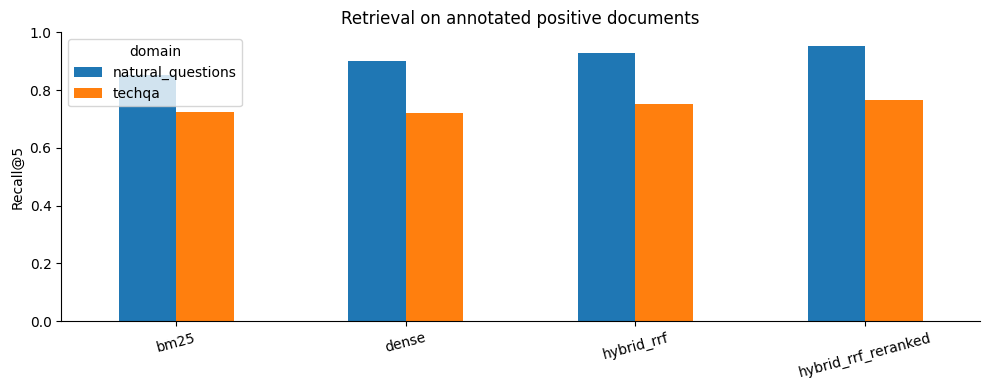

In [11]:
display(retrieval_metrics.pivot_table(index=['domain', 'retrieval_method', 'supported_examples'],
                                      columns='metric', values='value').round(4))
recall = retrieval_metrics[retrieval_metrics.metric.eq('Recall@5')]
fig, ax = plt.subplots()
recall.pivot(index='retrieval_method', columns='domain', values='value').plot.bar(ax=ax)
ax.set(ylabel='Recall@5', xlabel='', ylim=(0, 1), title='Retrieval on annotated positive documents')
ax.tick_params(axis='x', rotation=15)
fig.tight_layout()
fig.savefig(FIGURES / '02_recall_at_5.png', dpi=160)
plt.show()

### **Measured Local Retrieval Latency**

Reranked latency includes both Hybrid RRF and cross-encoder time.

In [12]:
timing = latency_summary(rankings)
display(timing.round(2))
save_table(cfg, 'retrieval_latency_summary', timing)
display(rankings[rankings.retrieval_method.eq('hybrid_rrf_reranked')]
        [['example_id', 'latency_ms', 'rerank_only_ms']].head())

,domain,retrieval_method,queries,mean_latency_ms,median_latency_ms,p95_latency_ms
0,natural_questions,bm25,1000,67.96,64.35,101.91
1,natural_questions,dense,1000,12.68,11.38,18.11
2,natural_questions,hybrid_rrf,1000,112.47,104.64,178.30
3,natural_questions,hybrid_rrf_reranked,1000,528.48,509.24,733.92
4,techqa,bm25,910,277.20,230.45,608.59
5,techqa,dense,910,17.92,17.83,26.50
6,techqa,hybrid_rrf,910,314.85,273.04,641.41
7,techqa,hybrid_rrf_reranked,910,407.20,365.49,741.31


,example_id,latency_ms,rerank_only_ms
3000,nq_-104036021879371599,670.6343,589.2870
3001,nq_-1051050103220761280,377.1210,312.8296
3002,nq_-1110132238118918750,481.9510,406.1323
3003,nq_-111554486016371163,340.1237,283.5418
3004,nq_-1123648516286545015,424.9403,357.0302


### **Results Interpretation**

Hybrid RRF captures most of the available retrieval gain. Reranking raises Recall@5 over Hybrid RRF by 2.4 percentage points on NQ and 1.5 points on TechQA, while Recall@10 is unchanged in both domains. It also adds about 416 ms per NQ query and 92 ms per TechQA query over the hybrid path.

Dense retrieval is the fastest and performs strongly on NQ, but fusion is more robust on TechQA. These results support Hybrid RRF as the standard retrieval route and reserve reranking for a potential escalation whose smaller quality gain must justify its latency.

---

# **Part 4: Conclusion**

Notebook 02 completed BM25, dense, Hybrid RRF, and reranked retrieval for all 1,910 queries. On gold-supported queries, reranking produced the best MRR and Recall@5 on NQ (0.838 and 0.952) and TechQA (0.654 and 0.766); Hybrid RRF and reranking tied at Recall@10 with 0.980 on NQ and 0.846 on TechQA. Dense retrieval was fastest at 12.7 ms on NQ and 17.9 ms on TechQA, while the complete reranked path averaged 528.5 and 407.2 ms. The results show that reranking improves top-rank quality, but its gain over Hybrid RRF is modest relative to its additional local latency.

---